In [1]:
import pandas as pd
import os

# ファイルパス
base_dir = r'C:\Users\xyz19\OneDrive\デスクトップ\予測モデルデータセット'
file_path = os.path.join(base_dir, 'regression_df_20260112_233447.xlsx')

# データを読み込む
print("データを読み込んでいます...")
regressionDF = pd.read_excel(file_path)

print("✓ データの読み込みが完了しました。")

データを読み込んでいます...
✓ データの読み込みが完了しました。


In [2]:
# データの基本情報
print(f"データ形状: {regressionDF.shape}")
print(f"行数: {len(regressionDF)}, 列数: {len(regressionDF.columns)}")

データ形状: (16388, 8)
行数: 16388, 列数: 8


In [3]:
# 列名を確認
regressionDF.columns.tolist()

['Area', 'Item', 'Year', 'SPEI', 'GSL', 'Hurs', 'TXX', 'Yield']

In [4]:
# データの詳細を確認
print("最初の5行:")
regressionDF.head()

最初の5行:


,Area,Item,Year,SPEI,GSL,Hurs,TXX,Yield
0,Afghanistan,Maize (corn),1961,-0.09,266.47,46.39,35.01,1400.0
1,Afghanistan,Maize (corn),1962,-0.22,265.56,46.38,36.46,1400.0
2,Afghanistan,Maize (corn),1963,-0.44,266.34,46.70,33.18,1426.0
3,Afghanistan,Maize (corn),1964,0.09,264.55,47.44,34.38,1425.7
4,Afghanistan,Maize (corn),1965,-0.15,265.76,47.21,33.30,1440.0


In [5]:
# データ型と基本統計
print("データ型:")
print(regressionDF.dtypes)
print("\n欠損値:")
print(regressionDF.isnull().sum())
print("\n穀物の種類:")
print(regressionDF['Item'].unique())
print("\n国の数:")
print(regressionDF['Area'].nunique())

データ型:
Area      object
Item      object
Year       int64
SPEI     float64
GSL      float64
Hurs     float64
TXX      float64
Yield    float64
dtype: object

欠損値:
Area     0
Item     0
Year     0
SPEI     0
GSL      0
Hurs     0
TXX      0
Yield    0
dtype: int64

穀物の種類:
['Maize (corn)' 'Rice' 'Wheat']

国の数:
156


In [6]:
# 特徴量の準備
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import numpy as np

# 気候データの列
climate_features = ['SPEI', 'GSL', 'Hurs', 'TXX']

# Area（国）をダミー変数化
area_dummies = pd.get_dummies(regressionDF['Area'], prefix='Area')

# Yearを特徴量として追加
year_feature = regressionDF[['Year']].copy()

# すべての特徴量を結合
X = pd.concat([
    regressionDF[climate_features],  # 気候データ
    area_dummies,                     # 国ダミー
    year_feature                      # Year
], axis=1)

# 目的変数
y = regressionDF['Yield'].copy()

print(f"特徴量の形状: {X.shape}")
print(f"特徴量の列数: {len(X.columns)}")
print(f"\n特徴量の最初の5行:")
X.head()

特徴量の形状: (16388, 161)
特徴量の列数: 161

特徴量の最初の5行:


,SPEI,GSL,Hurs,TXX,Area_Afghanistan,Area_Albania,Area_Algeria,Area_Angola,Area_Antigua and Barbuda,Area_Argentina,...,Area_Uganda,Area_Ukraine,Area_United Arab Emirates,Area_United States of America,Area_Uruguay,Area_Uzbekistan,Area_Vanuatu,Area_Zambia,Area_Zimbabwe,Year
0,-0.09,266.47,46.39,35.01,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1961
1,-0.22,265.56,46.38,36.46,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1962
2,-0.44,266.34,46.70,33.18,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1963
3,0.09,264.55,47.44,34.38,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1964
4,-0.15,265.76,47.21,33.30,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,1965


In [7]:
# XGBoostをインストール
import sys
import subprocess

try:
    import xgboost
    print("XGBoostは既にインストールされています。")
except ImportError:
    print("XGBoostをインストールしています...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
    print("XGBoostのインストールが完了しました。")
    # インストール後、再度インポートを試みる
    import importlib
    importlib.reload(sys.modules.get('sys', sys))

XGBoostは既にインストールされています。


In [11]:
# 各穀物ごとに30回のランダム分割でモデル性能を検証
try:
    from xgboost import XGBRegressor
    print("XGBoostを使用します。")
except ImportError:
    print("XGBoostが利用できないため、scikit-learnのGradientBoostingRegressorを使用します。")
    from sklearn.ensemble import GradientBoostingRegressor
    # XGBRegressorと同じインターフェースで使えるようにラッパーを作成
    class XGBRegressor:
        def __init__(self, n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1):
            self.model = GradientBoostingRegressor(
                n_estimators=n_estimators,
                max_depth=max_depth,
                learning_rate=learning_rate,
                random_state=random_state
            )
        def fit(self, X, y):
            return self.model.fit(X, y)
        def predict(self, X):
            return self.model.predict(X)
        @property
        def feature_importances_(self):
            return self.model.feature_importances_
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# 穀物の種類を取得
items = regressionDF['Item'].unique()
print(f"穀物の種類数: {len(items)}")
print(f"穀物リスト: {list(items)}")

# 検証回数
n_iterations = 30

# 各穀物ごとの結果を保存する辞書
all_results = {}

# 各穀物ごとに30回のランダム分割で検証
for item in items:
    print(f"\n{'='*60}")
    print(f"穀物: {item}")
    print(f"{'='*60}")
    
    # 該当する穀物のデータを抽出
    item_mask = regressionDF['Item'] == item
    X_item = X[item_mask].copy()
    y_item = y[item_mask].copy()
    
    print(f"データ数: {len(X_item)}")
    print(f"{n_iterations}回のランダム分割で検証を開始...")
    
    # 各回の結果を保存するリスト
    iteration_results = []
    
    # 30回のランダム分割を繰り返す
    for iteration in range(n_iterations):
        # ランダムシードを変更してランダム分割（80:20）
        X_train, X_test, y_train, y_test = train_test_split(
            X_item, y_item, test_size=0.2, random_state=iteration
        )
        
        # Gradient Boostingモデル（XGBoost）を作成
        model = XGBRegressor(
            n_estimators=200,
            max_depth=5,
            learning_rate=0.1,
            random_state=42,
            n_jobs=-1
        )
        
        # モデルの訓練
        model.fit(X_train, y_train)
        
        # 予測
        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)
        
        # 評価指標を計算
        train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
        test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        train_mae = mean_absolute_error(y_train, y_train_pred)
        test_mae = mean_absolute_error(y_test, y_test_pred)
        
        # 結果を保存
        iteration_results.append({
            'train_rmse': train_rmse,
            'test_rmse': test_rmse,
            'train_r2': train_r2,
            'test_r2': test_r2,
            'train_mae': train_mae,
            'test_mae': test_mae
        })
        
        # 進捗表示（10回ごと）
        if (iteration + 1) % 10 == 0:
            print(f"  完了: {iteration + 1}/{n_iterations}回")
    
    # 結果をDataFrameに変換
    results_df_item = pd.DataFrame(iteration_results)
    
    # 平均と標準偏差を計算
    summary = {
        'train_rmse_mean': results_df_item['train_rmse'].mean(),
        'train_rmse_std': results_df_item['train_rmse'].std(),
        'test_rmse_mean': results_df_item['test_rmse'].mean(),
        'test_rmse_std': results_df_item['test_rmse'].std(),
        'train_r2_mean': results_df_item['train_r2'].mean(),
        'train_r2_std': results_df_item['train_r2'].std(),
        'test_r2_mean': results_df_item['test_r2'].mean(),
        'test_r2_std': results_df_item['test_r2'].std(),
        'train_mae_mean': results_df_item['train_mae'].mean(),
        'train_mae_std': results_df_item['train_mae'].std(),
        'test_mae_mean': results_df_item['test_mae'].mean(),
        'test_mae_std': results_df_item['test_mae'].std(),
        'n_samples': len(X_item)
    }
    
    all_results[item] = {
        'summary': summary,
        'all_iterations': results_df_item
    }
    
    # 結果を表示
    print(f"\n【{n_iterations}回の平均結果】")
    print(f"訓練データ - RMSE: {summary['train_rmse_mean']:.4f} (±{summary['train_rmse_std']:.4f}), "
          f"R²: {summary['train_r2_mean']:.4f} (±{summary['train_r2_std']:.4f}), "
          f"MAE: {summary['train_mae_mean']:.4f} (±{summary['train_mae_std']:.4f})")
    print(f"テストデータ - RMSE: {summary['test_rmse_mean']:.4f} (±{summary['test_rmse_std']:.4f}), "
          f"R²: {summary['test_r2_mean']:.4f} (±{summary['test_r2_std']:.4f}), "
          f"MAE: {summary['test_mae_mean']:.4f} (±{summary['test_mae_std']:.4f})")

print(f"\n{'='*60}")
print(f"すべての穀物の{n_iterations}回検証が完了しました！")
print(f"{'='*60}")

XGBoostを使用します。
穀物の種類数: 3
穀物リスト: ['Maize (corn)', 'Rice', 'Wheat']

穀物: Maize (corn)
データ数: 6515
30回のランダム分割で検証を開始...
  完了: 10/30回
  完了: 20/30回
  完了: 30/30回

【30回の平均結果】
訓練データ - RMSE: 621.6822 (±7.3522), R²: 0.9594 (±0.0011), MAE: 433.8998 (±4.8656)
テストデータ - RMSE: 846.1431 (±53.7867), R²: 0.9217 (±0.0091), MAE: 520.7768 (±12.7860)

穀物: Rice
データ数: 5128
30回のランダム分割で検証を開始...
  完了: 10/30回
  完了: 20/30回
  完了: 30/30回

【30回の平均結果】
訓練データ - RMSE: 494.2286 (±5.8739), R²: 0.9152 (±0.0025), MAE: 362.4693 (±4.4202)
テストデータ - RMSE: 607.1300 (±23.9567), R²: 0.8689 (±0.0115), MAE: 442.0710 (±12.5600)

穀物: Wheat
データ数: 4745
30回のランダム分割で検証を開始...
  完了: 10/30回
  完了: 20/30回
  完了: 30/30回

【30回の平均結果】
訓練データ - RMSE: 391.6926 (±4.0416), R²: 0.9413 (±0.0016), MAE: 290.8919 (±3.0207)
テストデータ - RMSE: 493.2915 (±21.9981), R²: 0.9083 (±0.0091), MAE: 362.1140 (±9.2086)

すべての穀物の30回検証が完了しました！


In [12]:
# 全モデルの結果をまとめて表示（平均と標準偏差）
summary_results = {}
for item, result_dict in all_results.items():
    summary_results[item] = result_dict['summary']

summary_df = pd.DataFrame(summary_results).T
summary_df = summary_df.round(4)
print(f"各穀物のモデル性能（{n_iterations}回の平均 ± 標準偏差）:")
summary_df

各穀物のモデル性能（30回の平均 ± 標準偏差）:


,train_rmse_mean,train_rmse_std,test_rmse_mean,test_rmse_std,train_r2_mean,train_r2_std,test_r2_mean,test_r2_std,train_mae_mean,train_mae_std,test_mae_mean,test_mae_std,n_samples
Maize (corn),621.6822,7.3522,846.1431,53.7867,0.9594,0.0011,0.9217,0.0091,433.8998,4.8656,520.7768,12.7860,6515.0
Rice,494.2286,5.8739,607.1300,23.9567,0.9152,0.0025,0.8689,0.0115,362.4693,4.4202,442.0710,12.5600,5128.0
Wheat,391.6926,4.0416,493.2915,21.9981,0.9413,0.0016,0.9083,0.0091,290.8919,3.0207,362.1140,9.2086,4745.0


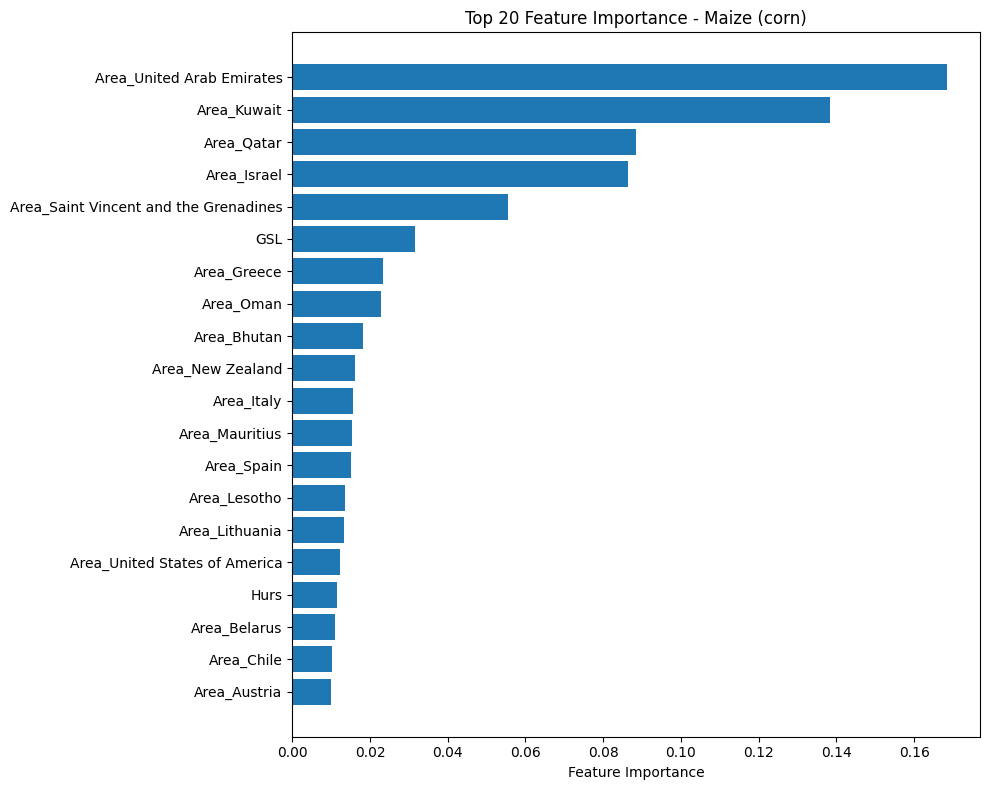

穀物 'Maize (corn)' の上位10特徴量:


,feature,importance
153,Area_United Arab Emirates,0.168537
81,Area_Kuwait,0.138290
121,Area_Qatar,0.088433
74,Area_Israel,0.086450
126,Area_Saint Vincent and the Grenadines,0.055559
1,GSL,0.031457
61,Area_Greece,0.023360
112,Area_Oman,0.022773
20,Area_Bhutan,0.018253
106,Area_New Zealand,0.016012


In [13]:
# 特徴量の重要度を可視化（最初の穀物の例、最後のモデルを使用）
import matplotlib.pyplot as plt

# 日本語フォントの設定
plt.rcParams['font.family'] = 'DejaVu Sans'

# 最初の穀物で最後のモデルを構築して特徴量重要度を取得
first_item = list(items)[0]
item_mask = regressionDF['Item'] == first_item
X_item = X[item_mask].copy()
y_item = y[item_mask].copy()

# 最後のランダム分割でモデルを構築
X_train, X_test, y_train, y_test = train_test_split(
    X_item, y_item, test_size=0.2, random_state=n_iterations-1
)

model_last = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)
model_last.fit(X_train, y_train)

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model_last.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
plt.barh(range(len(feature_importance)), feature_importance['importance'])
plt.yticks(range(len(feature_importance)), feature_importance['feature'])
plt.xlabel('Feature Importance')
plt.title(f'Top 20 Feature Importance - {first_item}')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"穀物 '{first_item}' の上位10特徴量:")
feature_importance.head(10)

In [24]:
# 2005年までを訓練、2006年以降をテストとし、テストR2でハイパーパラメータを選択
from itertools import product
from sklearn.metrics import r2_score

param_grid = {
    'n_estimators': [200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

param_list = list(product(
    param_grid['n_estimators'],
    param_grid['max_depth'],
    param_grid['learning_rate'],
    param_grid['subsample'],
    param_grid['colsample_bytree']
))

time_split_grid_results = {}
print("=== 2005年まで訓練 / 2006年以降テストで、テストR2を基準にチューニング ===")

for item in items:
    item_mask = regressionDF['Item'] == item
    train_mask = item_mask & (regressionDF['Year'] <= 2005)
    test_mask = item_mask & (regressionDF['Year'] > 2005)

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        print(f"{item}: 学習/テストデータ不足 (train={train_mask.sum()}, test={test_mask.sum()})")
        continue

    X_train, y_train = X.loc[train_mask], y.loc[train_mask]
    X_test, y_test = X.loc[test_mask], y.loc[test_mask]

    best_test_r2 = -1e9
    best_params = None
    best_train_r2 = None

    for (n_est, md, lr, subs, colsub) in param_list:
        params = {
            'n_estimators': n_est,
            'max_depth': md,
            'learning_rate': lr,
            'subsample': subs,
            'colsample_bytree': colsub,
            'random_state': 42,
            'n_jobs': -1
        }
        model = XGBRegressor(**params)
        model.fit(X_train, y_train)
        train_r2 = r2_score(y_train, model.predict(X_train))
        test_r2 = r2_score(y_test, model.predict(X_test))

        if test_r2 > best_test_r2:
            best_test_r2 = test_r2
            best_train_r2 = train_r2
            best_params = params

    time_split_grid_results[item] = {
        'best_params': best_params,
        'best_test_r2': best_test_r2,
        'best_train_r2': best_train_r2,
        'train_size': train_mask.sum(),
        'test_size': test_mask.sum()
    }

    print(f"\n--- {item} ---")
    print("best_params:", best_params)
    print(f"train_R2: {best_train_r2:.4f} | test_R2: {best_test_r2:.4f} | train_n={train_mask.sum()} / test_n={test_mask.sum()}")

print("\n=== チューニング完了 (テストR2基準) ===")
time_split_grid_results

=== 2005年まで訓練 / 2006年以降テストで、テストR2を基準にチューニング ===

--- Maize (corn) ---
best_params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 1.0, 'random_state': 42, 'n_jobs': -1}
train_R2: 0.9892 | test_R2: 0.8325 | train_n=5413 / test_n=1102

--- Rice ---
best_params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1}
train_R2: 0.9772 | test_R2: 0.7955 | train_n=4325 / test_n=803

--- Wheat ---
best_params: {'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8, 'random_state': 42, 'n_jobs': -1}
train_R2: 0.9840 | test_R2: 0.8873 | train_n=3906 / test_n=839

=== チューニング完了 (テストR2基準) ===


{'Maize (corn)': {'best_params': {'n_estimators': 300,
   'max_depth': 7,
   'learning_rate': 0.1,
   'subsample': 0.8,
   'colsample_bytree': 1.0,
   'random_state': 42,
   'n_jobs': -1},
  'best_test_r2': 0.8324763315158292,
  'best_train_r2': 0.9891870912245362,
  'train_size': np.int64(5413),
  'test_size': np.int64(1102)},
 'Rice': {'best_params': {'n_estimators': 300,
   'max_depth': 7,
   'learning_rate': 0.1,
   'subsample': 0.8,
   'colsample_bytree': 0.8,
   'random_state': 42,
   'n_jobs': -1},
  'best_test_r2': 0.7955156327926269,
  'best_train_r2': 0.9772367199637806,
  'train_size': np.int64(4325),
  'test_size': np.int64(803)},
 'Wheat': {'best_params': {'n_estimators': 300,
   'max_depth': 7,
   'learning_rate': 0.1,
   'subsample': 0.8,
   'colsample_bytree': 0.8,
   'random_state': 42,
   'n_jobs': -1},
  'best_test_r2': 0.8872985507928047,
  'best_train_r2': 0.9840097931621193,
  'train_size': np.int64(3906),
  'test_size': np.int64(839)}}

In [ ]:
# 決定係数（R²）：穀物ごと全体のテストR² ＋ 国ごとR²（サンプル数十分な国のみ）
from sklearn.metrics import r2_score
from xgboost import XGBRegressor

MIN_TEST_N = 5  # 国ごとR²を出すのに必要なテスト標本数（少ないとR²が不安定）

print("=== 決定係数（R²）：テストデータ（2006年以降） ===\n")

for item in ['Maize (corn)', 'Rice', 'Wheat']:
    if item not in time_split_grid_results:
        continue

    item_mask = regressionDF['Item'] == item
    train_mask = item_mask & (regressionDF['Year'] <= 2005)
    test_mask = item_mask & (regressionDF['Year'] > 2005)

    if train_mask.sum() == 0 or test_mask.sum() == 0:
        continue

    best_params = time_split_grid_results[item]['best_params']
    model = XGBRegressor(**best_params)
    model.fit(X.loc[train_mask], y.loc[train_mask])

    y_test = y.loc[test_mask]
    y_test_pred = model.predict(X.loc[test_mask])
    r2_overall = r2_score(y_test, y_test_pred)
    n_test = int(test_mask.sum())

    print(f"【{item}】 テスト n={n_test}")
    print(f"  全体の決定係数 R² = {r2_overall:.4f}")
    print()

    test_df = regressionDF.loc[test_mask].copy()
    test_df['y_pred'] = y_test_pred

    area_r2 = []
    for area in test_df['Area'].unique():
        m = test_df['Area'] == area
        n = int(m.sum())
        if n < MIN_TEST_N:
            continue
        r2 = r2_score(test_df.loc[m, 'Yield'], test_df.loc[m, 'y_pred'])
        area_r2.append((area, r2, n))

    area_r2.sort(key=lambda x: x[1], reverse=True)
    print(f"  予測精度順位（R²の高い順、テスト標本数>={MIN_TEST_N}の国のみ、{len(area_r2)}ヶ国）:")
    print("  " + "=" * 68)
    for i, (area, r2, n) in enumerate(area_r2, 1):
        print(f"  予測精度{i:3d}位. {area:38s} R²={r2:7.4f}  (n={n})")
    print("  " + "=" * 68)
    print()

=== 決定係数（R²）：テストデータ（2006年以降） ===

【Maize (corn)】 テスト n=1102
  全体の決定係数 R² = 0.8325

  予測精度順位（R²の高い順、テスト標本数>=5の国のみ、138ヶ国）:
  予測精度  1位. Croatia                                R²= 0.1816  (n=8)
  予測精度  2位. Azerbaijan                             R²= 0.0323  (n=8)
  予測精度  3位. Poland                                 R²= 0.0245  (n=8)
  予測精度  4位. Timor-Leste                            R²= 0.0225  (n=8)
  予測精度  5位. Belgium                                R²= 0.0221  (n=8)
  予測精度  6位. Morocco                                R²=-0.0243  (n=8)
  予測精度  7位. Chile                                  R²=-0.0290  (n=8)
  予測精度  8位. Guinea                                 R²=-0.0333  (n=8)
  予測精度  9位. Italy                                  R²=-0.0434  (n=8)
  予測精度 10位. Russian Federation                     R²=-0.0437  (n=8)
  予測精度 11位. Bosnia and Herzegovina                 R²=-0.0486  (n=8)
  予測精度 12位. Albania                                R²=-0.0938  (n=8)
  予測精度 13位. Iraq                                   

: 